In [52]:
# ── Imports + circuit builders ────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fractions import Fraction
from math import gcd, log, ceil

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import UnitaryGate, QFT
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager


def build_mod_mult_unitary(k, N, n_bits):
    """Build the unitary matrix for 'multiply by k mod N'.
    Each input state |x> maps to |x*k mod N> for valid inputs.
    This is a permutation matrix — always unitary.
    """
    dim = 2**n_bits
    U = np.zeros((dim, dim))
    for x in range(dim):
        if x == 0:
            U[0][0] = 1
        elif x < N and gcd(x, N) == 1:
            y = (x * k) % N
            U[y][x] = 1
        else:
            U[x][x] = 1
    return U


def build_shor_circuit(N, a, num_control, num_target):
    """Build the complete Shor's circuit with named registers.
    Returns the circuit and the number of controlled multiplications applied.
    """
    control = QuantumRegister(num_control, name='Counting')
    target  = QuantumRegister(num_target,  name='Target')
    output  = ClassicalRegister(num_control, name='output')
    circuit = QuantumCircuit(control, target, output)

    circuit.x(num_control)
    for k in range(num_control):
        circuit.h(k)
    circuit.barrier()

    n_mod_mults = 0
    for k in range(num_control):
        power = pow(a, 2**k, N)
        if power == 1:
            continue
        U      = build_mod_mult_unitary(power, N, num_target)
        gate   = UnitaryGate(U)
        gate.name = f'M_{power}'
        c_gate = gate.control()
        circuit.compose(c_gate,
                        qubits=[k] + list(range(num_control, num_control + num_target)),
                        inplace=True)
        n_mod_mults += 1

    circuit.barrier()
    circuit.compose(QFT(num_control, inverse=True), qubits=control, inplace=True)
    circuit.barrier()
    circuit.measure(control, output)

    return circuit, n_mod_mults


print('Imports and circuit builders loaded.')

Imports and circuit builders loaded.


In [53]:
# ── Connect to IBM Quantum (once, shared for both circuits) ───────────────
#
# First time only — paste your API token and CRN, then comment out after saving.
#
QiskitRuntimeService.save_account(
    channel='ibm_quantum_platform',
    token='zbAsMNyeoo4YfwQj5PZAtT7HS4Srv0jKZLb8VAdXExsj',
    instance='crn:v1:bluemix:public:quantum-computing:us-east:a/7b51e867d80d4d91b91245206f368ad4:681060a7-5b8a-4ade-b759-c1690e9159bc::',
    overwrite=True
)

service = QiskitRuntimeService(channel='ibm_quantum_platform')
backend = service.backend('ibm_fez')

print(f'Connected to:     {backend.name}')
print(f'Qubits available: {backend.num_qubits}')
print(f'Processor:        {backend.processor_type}')

Connected to:     ibm_fez
Qubits available: 156
Processor:        {'family': 'Heron', 'revision': '2'}


In [54]:
# ── Build both circuits ───────────────────────────────────────────────────
a = 2

# N=15
N15          = 15
nt15         = ceil(log(N15, 2))   # 4 target qubits
nc15         = 2 * nt15            # 8 counting qubits
circuit15, n_mults15 = build_shor_circuit(N15, a, nc15, nt15)

# N=21
N21          = 21
nt21         = ceil(log(N21, 2))   # 5 target qubits
nc21         = 2 * nt21            # 10 counting qubits
circuit21, n_mults21 = build_shor_circuit(N21, a, nc21, nt21)

print(f'N=15: {nc15} counting + {nt15} target = {nc15+nt15} qubits, {n_mults15} controlled multiplications')
print(f'N=21: {nc21} counting + {nt21} target = {nc21+nt21} qubits, {n_mults21} controlled multiplications')

C:\Users\User\AppData\Local\Temp\ipykernel_27096\409482757.py:61: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit.compose(QFT(num_control, inverse=True), qubits=control, inplace=True)


N=15: 8 counting + 4 target = 12 qubits, 2 controlled multiplications
N=21: 10 counting + 5 target = 15 qubits, 10 controlled multiplications


In [55]:
# ── Transpile both circuits for the real device ───────────────────────────
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)

compiled15 = pm.run(circuit15)
compiled21 = pm.run(circuit21)

gates15 = sum(compiled15.count_ops().values())
gates21 = sum(compiled21.count_ops().values())

print(f'N=15  →  Total gates: {gates15:,}   Depth: {compiled15.depth()}')
print(f'N=21  →  Total gates: {gates21:,}   Depth: {compiled21.depth()}')

N=15  →  Total gates: 6,804   Depth: 4203
N=21  →  Total gates: 126,108   Depth: 75897


In [56]:
# ── Submit both jobs ──────────────────────────────────────────────────────
#
# Both jobs are submitted back-to-back before waiting for results.
# Save both Job IDs — if session disconnects, retrieve with:
#   job15 = service.job('JOB_ID_15')
#   job21 = service.job('JOB_ID_21')

shots   = 4096
sampler = SamplerV2(backend)

job15 = sampler.run([compiled15], shots=shots)
job21 = sampler.run([compiled21], shots=shots)

print(f'Both jobs submitted!')
print(f'N=15 Job ID: {job15.job_id()}')
print(f'N=21 Job ID: {job21.job_id()}')
print(f'Shots: {shots} each')

Both jobs submitted!
N=15 Job ID: d6u4jr2f84ks73ddrv2g
N=21 Job ID: d6u4jsk69uic73chr9qg
Shots: 4096 each


In [57]:
# ── Retrieve both results ─────────────────────────────────────────────────

result15 = job15.result()
result21 = job21.result()

counts15 = result15[0].data.output.get_counts()
counts21 = result21[0].data.output.get_counts()

print(f'N=15 complete:  {len(counts15)} unique outcomes  |  top: {max(counts15.values())} shots ({100*max(counts15.values())/shots:.1f}%)')
print(f'N=21 complete:  {len(counts21)} unique outcomes  |  top: {max(counts21.values())} shots ({100*max(counts21.values())/shots:.1f}%)')

N=15 complete:  256 unique outcomes  |  top: 35 shots (0.9%)
N=21 complete:  973 unique outcomes  |  top: 16 shots (0.4%)


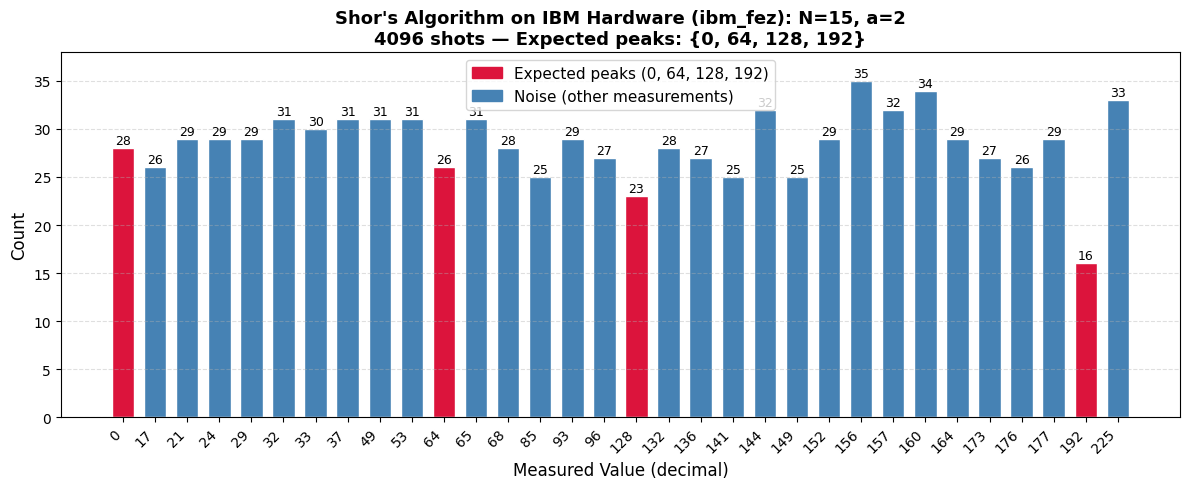

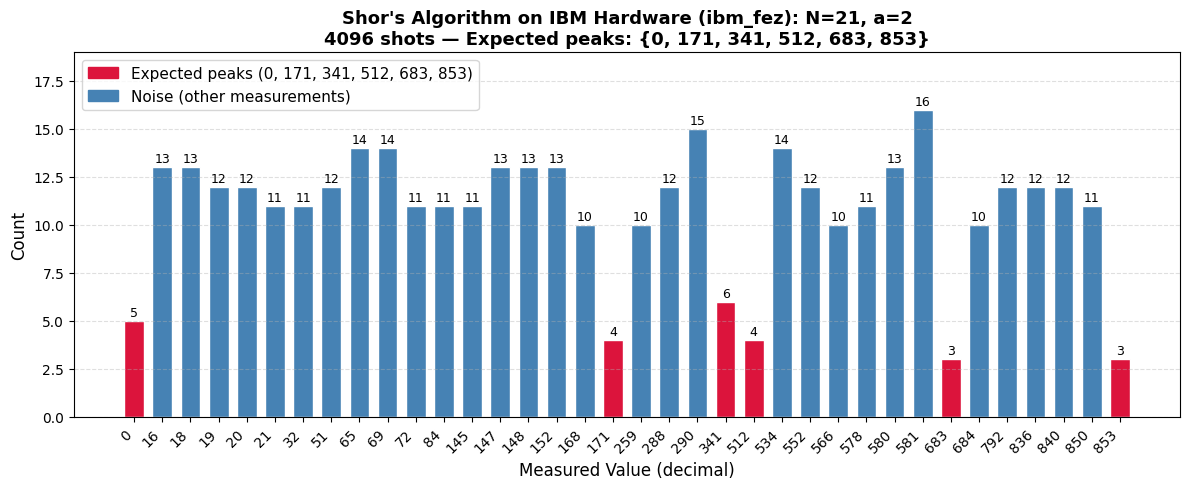

In [58]:
# ── Histograms — N=15 and N=21 (separate figures) ────────────────────────
import matplotlib.patches as mpatches

def plot_clean_histogram(counts, shots, expected_peaks, title, filename=None):
    """Show top 30 bars by count, always include expected peaks.
    Filters out very low counts to keep the plot readable.
    """
    decimal_counts = {int(k, 2): v for k, v in counts.items()}

    # Always include expected peaks; fill remaining slots with highest counts
    top_keys = set(k for k, v in sorted(decimal_counts.items(),
                                         key=lambda x: -x[1])[:30])
    top_keys |= set(expected_peaks)
    top = {k: decimal_counts.get(k, 0) for k in sorted(top_keys) if decimal_counts.get(k, 0) > 0}

    keys   = list(top.keys())
    vals   = list(top.values())
    colors = ['crimson' if k in expected_peaks else 'steelblue' for k in keys]

    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(range(len(keys)), vals, color=colors, edgecolor='white', width=0.7)

    for bar, count in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                str(count), ha='center', va='bottom', fontsize=9)

    ax.set_xticks(range(len(keys)))
    ax.set_xticklabels([str(k) for k in keys], rotation=45, ha='right', fontsize=10)
    ax.set_xlabel('Measured Value (decimal)', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    peak_str = ', '.join(str(p) for p in sorted(expected_peaks))
    ax.legend(handles=[
        mpatches.Patch(color='crimson',   label=f'Expected peaks ({peak_str})'),
        mpatches.Patch(color='steelblue', label='Noise (other measurements)'),
    ], fontsize=11)
    ax.set_ylim(0, max(vals) + 3)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    if filename:
        fig.savefig(filename, dpi=200, bbox_inches='tight', facecolor='white')
        print(f'Saved: {filename}')
    plt.show()

# N=15
plot_clean_histogram(
    counts15, shots,
    expected_peaks={0, 64, 128, 192},
    title=f"Shor's Algorithm on IBM Hardware (ibm_fez): N=15, a=2\n{shots} shots — Expected peaks: {{0, 64, 128, 192}}"
)

# N=21
plot_clean_histogram(
    counts21, shots,
    expected_peaks={0, 171, 341, 512, 683, 853},
    title=f"Shor's Algorithm on IBM Hardware (ibm_fez): N=21, a=2\n{shots} shots — Expected peaks: {{0, 171, 341, 512, 683, 853}}"
)


In [59]:
# ── Phase extraction — N=15 ───────────────────────────────────────────────

rows_phase15 = []
for bitstring in sorted(counts15, key=lambda x: counts15[x], reverse=True):
    count   = counts15[bitstring]
    decimal = int(bitstring, 2)
    phase   = decimal / (2**nc15)
    rows_phase15.append([
        bitstring, decimal, count,
        f'{count/shots:.1%}',
        f'{decimal}/{2**nc15} = {phase:.4f}'
    ])

print('Phase extraction for N=15, a=2:')
df_phase15 = pd.DataFrame(rows_phase15[:15],
    columns=['Bitstring', 'Decimal', 'Count', 'Probability', 'Phase'])
print(df_phase15.to_string(index=False))

Phase extraction for N=15, a=2:
Bitstring  Decimal  Count Probability            Phase
 10011100      156     35        0.9% 156/256 = 0.6094
 10100000      160     34        0.8% 160/256 = 0.6250
 11100001      225     33        0.8% 225/256 = 0.8789
 10011101      157     32        0.8% 157/256 = 0.6133
 10010000      144     32        0.8% 144/256 = 0.5625
 00110101       53     31        0.8%  53/256 = 0.2070
 00110001       49     31        0.8%  49/256 = 0.1914
 00100101       37     31        0.8%  37/256 = 0.1445
 01000001       65     31        0.8%  65/256 = 0.2539
 00100000       32     31        0.8%  32/256 = 0.1250
 00100001       33     30        0.7%  33/256 = 0.1289
 00011101       29     29        0.7%  29/256 = 0.1133
 00011000       24     29        0.7%  24/256 = 0.0938
 00010101       21     29        0.7%  21/256 = 0.0820
 01011101       93     29        0.7%  93/256 = 0.3633


In [60]:
# ── Phase extraction — N=21 ───────────────────────────────────────────────

rows_phase21 = []
for bitstring in sorted(counts21, key=lambda x: counts21[x], reverse=True):
    count   = counts21[bitstring]
    decimal = int(bitstring, 2)
    phase   = decimal / (2**nc21)
    rows_phase21.append([
        bitstring, decimal, count,
        f'{count/shots:.1%}',
        f'{decimal}/{2**nc21} = {phase:.4f}'
    ])

print('Phase extraction for N=21, a=2:')
df_phase21 = pd.DataFrame(rows_phase21[:15],
    columns=['Bitstring', 'Decimal', 'Count', 'Probability', 'Phase'])
print(df_phase21.to_string(index=False))

Phase extraction for N=21, a=2:
 Bitstring  Decimal  Count Probability             Phase
1001000101      581     16        0.4% 581/1024 = 0.5674
0100100010      290     15        0.4% 290/1024 = 0.2832
1000010110      534     14        0.3% 534/1024 = 0.5215
0001000101       69     14        0.3%  69/1024 = 0.0674
0001000001       65     14        0.3%  65/1024 = 0.0635
0010010011      147     13        0.3% 147/1024 = 0.1436
0010010100      148     13        0.3% 148/1024 = 0.1445
0010011000      152     13        0.3% 152/1024 = 0.1484
0000010010       18     13        0.3%  18/1024 = 0.0176
1001000100      580     13        0.3% 580/1024 = 0.5664
0000010000       16     13        0.3%  16/1024 = 0.0156
0000110011       51     12        0.3%  51/1024 = 0.0498
0100100000      288     12        0.3% 288/1024 = 0.2812
1101001000      840     12        0.3% 840/1024 = 0.8203
1000101000      552     12        0.3% 552/1024 = 0.5391


In [61]:
# ── Period extraction — N=15 (all successful rows shown) ──────────────────

def extract_periods(counts, N, a, num_control, shots):
    """Iterate all outcomes, return (df_all, success_shots)."""
    rows, success_shots = [], 0
    for bitstring in sorted(counts, key=lambda x: counts[x], reverse=True):
        count   = counts[bitstring]
        decimal = int(bitstring, 2)
        phase   = decimal / (2**num_control)
        frac    = Fraction(phase).limit_denominator(N)
        r       = frac.denominator
        valid   = r > 1 and pow(a, r, N) == 1
        factors = ''
        if valid and r % 2 == 0:
            x = pow(a, r // 2, N)
            if x != N - 1:
                f1, f2 = gcd(x - 1, N), gcd(x + 1, N)
                if 1 < f1 < N:
                    factors = f'{f1} x {N // f1}'
                    success_shots += count
                elif 1 < f2 < N:
                    factors = f'{f2} x {N // f2}'
                    success_shots += count
        rows.append([f'{phase:.4f}', f'{frac.numerator}/{frac.denominator}',
                     r, 'Yes' if valid else 'No', count,
                     factors if factors else '-'])
    df = pd.DataFrame(rows, columns=['Phase','Fraction','Guess for r','Valid','Count','Factors'])
    return df, success_shots

df15, success15 = extract_periods(counts15, N15, a, nc15, shots)

successful15 = df15[df15['Factors'] != '-'].sort_values('Count', ascending=False)
failed15     = df15[df15['Factors'] == '-'].sort_values('Count', ascending=False).head(10)

print(f'Period extraction for N=15, a=2:')
print(f'\n--- Successful outcomes ({len(successful15)} rows, {success15} shots total) ---')
print(successful15.to_string(index=False))
print(f'\n--- Top 10 unsuccessful outcomes (for comparison) ---')
print(failed15.to_string(index=False))
print(f'\nSuccess rate: {100*success15/shots:.1f}%  ({success15}/{shots} shots)')
if success15 > 0:
    print(f'Factors found: 3 x 5 = 15  \u2713')
    print(f'Avg shots to first success: {round(shots/success15)}')

Period extraction for N=15, a=2:

--- Successful outcomes (22 rows, 347 shots total) ---
 Phase Fraction  Guess for r Valid  Count Factors
0.2539      1/4            4   Yes     31   3 x 5
0.0820     1/12           12   Yes     29   3 x 5
0.2500      1/4            4   Yes     26   3 x 5
0.5820     7/12           12   Yes     25   3 x 5
0.7539      3/4            4   Yes     23   3 x 5
0.5781     7/12           12   Yes     20   3 x 5
0.0859     1/12           12   Yes     20   3 x 5
0.2578      1/4            4   Yes     17   3 x 5
0.4219     5/12           12   Yes     16   3 x 5
0.7500      3/4            4   Yes     16   3 x 5
0.4102     5/12           12   Yes     15   3 x 5
0.9141    11/12           12   Yes     14   3 x 5
0.5859     7/12           12   Yes     14   3 x 5
0.7461      3/4            4   Yes     13   3 x 5
0.4141     5/12           12   Yes     12   3 x 5
0.5898     7/12           12   Yes     12   3 x 5
0.7578      3/4            4   Yes     10   3 x 5
0.2461     

In [62]:
# ── Period extraction — N=21 (all successful rows shown) ──────────────────

df21, success21 = extract_periods(counts21, N21, a, nc21, shots)

successful21 = df21[df21['Factors'] != '-'].sort_values('Count', ascending=False)
failed21     = df21[df21['Factors'] == '-'].sort_values('Count', ascending=False).head(10)

print(f'Period extraction for N=21, a=2:')
print(f'\n--- Successful outcomes ({len(successful21)} rows, {success21} shots total) ---')
print(successful21.to_string(index=False))
print(f'\n--- Top 10 unsuccessful outcomes (for comparison) ---')
print(failed21.to_string(index=False))
print(f'\nSuccess rate: {100*success21/shots:.1f}%  ({success21}/{shots} shots)')
if success21 > 0:
    print(f'Factors found: 3 x 7 = 21  \u2713')
    print(f'Avg shots to first success: {round(shots/success21)}')
else:
    print('No successful factorisation.')
    print('Circuit depth far exceeds hardware coherence limits.')

Period extraction for N=21, a=2:

--- Successful outcomes (52 rows, 232 shots total) ---
 Phase Fraction  Guess for r Valid  Count Factors
0.2812     5/18           18   Yes     12   7 x 3
0.8301      5/6            6   Yes     11   7 x 3
0.1641      1/6            6   Yes     10   7 x 3
0.0547     1/18           18   Yes      8   7 x 3
0.1680      1/6            6   Yes      8   7 x 3
0.2754     5/18           18   Yes      8   7 x 3
0.2773     5/18           18   Yes      8   7 x 3
0.1631      1/6            6   Yes      8   7 x 3
0.8359      5/6            6   Yes      7   7 x 3
0.3926     7/18           18   Yes      7   7 x 3
0.6113    11/18           18   Yes      6   7 x 3
0.8320      5/6            6   Yes      6   7 x 3
0.1689      1/6            6   Yes      6   7 x 3
0.8311      5/6            6   Yes      6   7 x 3
0.6104    11/18           18   Yes      6   7 x 3
0.0557     1/18           18   Yes      5   7 x 3
0.8340      5/6            6   Yes      5   7 x 3
0.1650     

In [63]:
# ── Theoretical random-chance success rate for continued fractions algorithm on every possible values ────────────────────────────────
from fractions import Fraction
from math import gcd

def random_success_rate(N, a, num_control):
    possible  = 2**num_control
    lucky = sum(
        1 for d in range(possible)
        if (lambda r: r > 1 and pow(a, r, N) == 1 and r % 2 == 0 and
            (lambda x: x != N-1 and
             (1 < gcd(x-1, N) < N or 1 < gcd(x+1, N) < N)
            )(pow(a, r//2, N))
           )(Fraction(d/possible).limit_denominator(N).denominator)
    )
    return lucky, possible, 100 * lucky / possible

lucky15, pos15, pct15 = random_success_rate(N=15, a=2, num_control=8)
lucky21, pos21, pct21 = random_success_rate(N=21, a=2, num_control=10)

print(f'N=15: {lucky15}/{pos15} outcomes give correct factors = {pct15:.2f}% by random chance')
print(f'N=21: {lucky21}/{pos21} outcomes give correct factors = {pct21:.2f}% by random chance')

N=15: 22/256 outcomes give correct factors = 8.59% by random chance
N=21: 52/1024 outcomes give correct factors = 5.08% by random chance
